# Audio Captioning -- Results Comparison

**Baseline config:** 2-layer MLP projection, prefix_len=8, dropout=0.3, weight_decay=0.1, batch_size=8, greedy decoding.  
**LRs:** tuned per model via Optuna (16 trials, 8 proxy epochs).  
**Evaluation:** stage 2 (projection + LM fine-tuned), CLAP precomputed embeddings.

Sections:
1. Baseline comparison across models
2. Architecture ablation tables per model
3. Training curves (val loss per epoch)
4. Sample predictions (best, worst, failure cases)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("../results")
MODELS = ["gpt2", "t5", "opt", "phi2", "llama"]
METRICS = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr", "FENSE"]

In [2]:
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None


def collect_eval_results():
    """Collect all ablation eval JSONs into a flat list of dicts."""
    rows = []
    for model in MODELS:
        model_dir = RESULTS_DIR / model
        if not model_dir.exists():
            continue
        for f in sorted(model_dir.glob(f"{model}_ablation_*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"{model}_ablation_", "")
            row = {"model": model, "tag": tag, **d["metrics"]}
            rows.append(row)
    return pd.DataFrame(rows)


def collect_training_results():
    """Collect all stage1/stage2 training JSONs."""
    rows = []
    for model in MODELS:
        model_dir = RESULTS_DIR / model
        if not model_dir.exists():
            continue
        for f in sorted(model_dir.glob(f"*_stage*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"_stage{d['stage']}", "")
            rows.append({
                "model": model,
                "tag": tag,
                "stage": d["stage"],
                "best_val_loss": d["best_val_loss"],
                "stopped_epoch": d["stopped_epoch"],
                "history": d["history"],
                "hyperparams": d["hyperparams"],
            })
    return rows


eval_df = collect_eval_results()
training_results = collect_training_results()
print(f"Loaded {len(eval_df)} eval results, {len(training_results)} training results")

Loaded 21 eval results, 42 training results


## 1. Baseline Comparison Across Models

In [3]:
baselines = eval_df[eval_df["tag"] == eval_df["model"]].copy()
if len(baselines) > 0:
    baselines = baselines.set_index("model")[METRICS].round(4)
    baselines = baselines.reindex([m for m in MODELS if m in baselines.index])
    display(baselines.style.background_gradient(cmap="Greys", vmin=-0.5, axis=None, subset=METRICS))
else:
    print("No baseline results found.")

,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
model,,,,,,
gpt2,0.283800,0.061000,0.203800,0.238400,0.345200,0.376000
t5,0.298000,0.057800,0.198400,0.233900,0.328700,0.334000
opt,0.275800,0.059500,0.212100,0.231800,0.344200,0.366200


## 2. Architecture Ablation Tables

In [4]:
BASELINE_DESC = "Baseline: depth=2, prefix_len=8, dropout=0.3"

for model in MODELS:
    model_df = eval_df[eval_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Architecture Ablations")
    print(f"  {BASELINE_DESC}")
    print(f"{'='*60}")
    table = model_df.set_index("tag")[METRICS].round(4)
    styled = table.style
    for col in METRICS:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=table[col].min() - 0.02)
    display(styled)


  GPT2 -- Architecture Ablations
  Baseline: depth=2, prefix_len=8, dropout=0.3


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
tag,,,,,,
gpt2,0.283800,0.061000,0.203800,0.238400,0.345200,0.376000
gpt2_depth1,0.279500,0.052000,0.200400,0.230000,0.290400,0.353000
gpt2_depth3,0.297000,0.065200,0.219100,0.244200,0.374600,0.402000
gpt2_drop0.1,0.293900,0.064900,0.209100,0.242200,0.345400,0.382500
gpt2_drop0.5,0.269700,0.048700,0.189300,0.222600,0.271300,0.395200
gpt2_prefix16,0.293600,0.063900,0.207800,0.237600,0.355100,0.362100
gpt2_prefix4,0.277100,0.059800,0.208900,0.238200,0.378600,0.393900



  T5 -- Architecture Ablations
  Baseline: depth=2, prefix_len=8, dropout=0.3


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
tag,,,,,,
t5,0.298000,0.057800,0.198400,0.233900,0.328700,0.334000
t5_depth1,0.126000,0.033700,0.091500,0.117400,0.115100,0.031700
t5_depth3,0.073600,0.013600,0.054100,0.093900,0.040000,0.028400
t5_drop0.1,0.267000,0.052900,0.182800,0.235200,0.276900,0.372400
t5_drop0.5,0.290400,0.056700,0.194100,0.238400,0.321600,0.385000
t5_prefix16,0.277000,0.050500,0.185300,0.235000,0.284700,0.381400
t5_prefix4,0.284400,0.054500,0.191300,0.236000,0.321800,0.400900



  OPT -- Architecture Ablations
  Baseline: depth=2, prefix_len=8, dropout=0.3


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
tag,,,,,,
opt,0.275800,0.059500,0.212100,0.231800,0.344200,0.366200
opt_depth1,0.267600,0.047000,0.185100,0.222000,0.267900,0.374300
opt_depth3,0.264600,0.051400,0.193500,0.226000,0.304600,0.385600
opt_drop0.1,0.297600,0.068300,0.220400,0.249800,0.386100,0.392900
opt_drop0.5,0.274300,0.063100,0.212600,0.229600,0.348500,0.392900
opt_prefix16,0.289300,0.062100,0.214200,0.237300,0.351400,0.403500
opt_prefix4,0.291200,0.057900,0.206600,0.238200,0.318800,0.417200


## 3. Training Curves

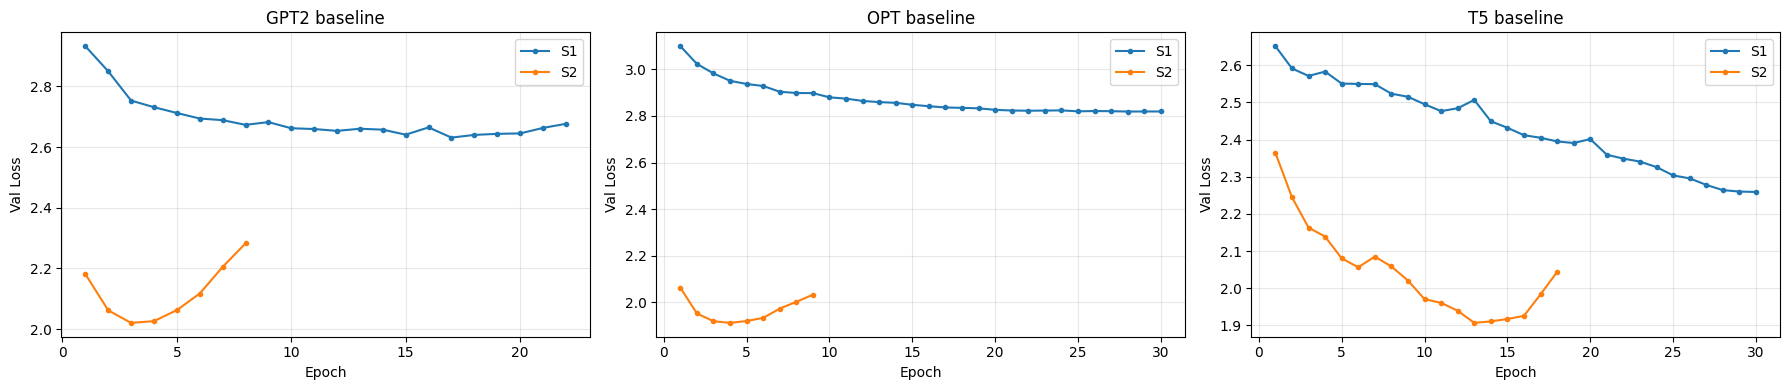

In [5]:
# Baseline training curves (S1 + S2) for each model
baseline_training = [r for r in training_results if r["tag"] == r["model"]]
models_with_data = sorted(set(r["model"] for r in baseline_training))

if models_with_data:
    fig, axes = plt.subplots(1, len(models_with_data), figsize=(6 * len(models_with_data), 4), squeeze=False)
    for idx, model in enumerate(models_with_data):
        ax = axes[0][idx]
        for r in baseline_training:
            if r["model"] != model:
                continue
            epochs = [h["epoch"] for h in r["history"]]
            val_loss = [h["val_loss"] for h in r["history"]]
            ax.plot(epochs, val_loss, marker="o", markersize=3, label=f"S{r['stage']}")
        ax.set_title(f"{model.upper()} baseline")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Val Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No baseline training results found.")

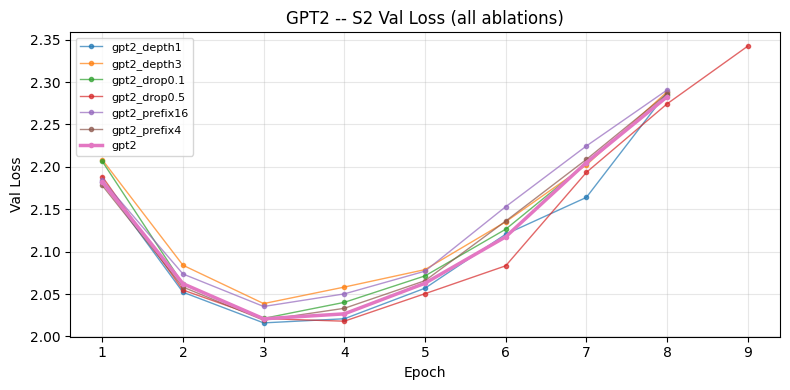

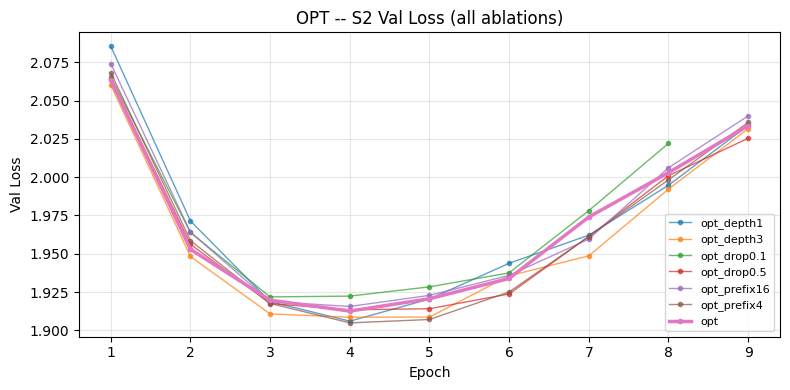

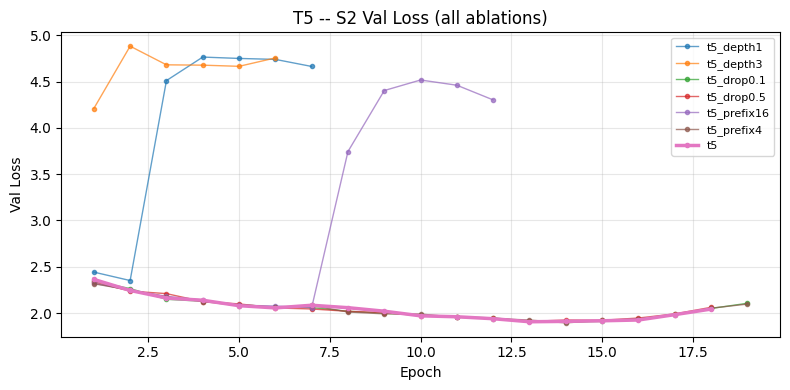

In [6]:
# S2 training curves for all ablation variants per model
s2_results = [r for r in training_results if r["stage"] == 2]
models_with_s2 = sorted(set(r["model"] for r in s2_results))

for model in models_with_s2:
    model_runs = [r for r in s2_results if r["model"] == model]
    fig, ax = plt.subplots(figsize=(8, 4))
    for r in model_runs:
        epochs = [h["epoch"] for h in r["history"]]
        val_loss = [h["val_loss"] for h in r["history"]]
        label = r["tag"]
        is_baseline = r["tag"] == r["model"]
        ax.plot(epochs, val_loss, marker="o", markersize=3, label=label,
                linewidth=2.5 if is_baseline else 1, alpha=1.0 if is_baseline else 0.7)
    ax.set_title(f"{model.upper()} -- S2 Val Loss (all ablations)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Sample Predictions

In [7]:
import torch
from fense.evaluator import Evaluator

fense_eval = Evaluator(device="cuda" if torch.cuda.is_available() else "cpu")


def score_predictions(predictions):
    """Score each prediction with sentence-level FENSE (batched)."""
    hyps = [p["hypothesis"] for p in predictions]
    refs = [[p["reference"]] for p in predictions]
    scores = fense_eval.corpus_score(hyps, refs, agg_score="none")
    scored = [{**p, "fense": float(s)} for p, s in zip(predictions, scores)]
    return sorted(scored, key=lambda x: x["fense"], reverse=True)


def show_predictions(scored, title, indices):
    """Display selected predictions."""
    print(f"\n--- {title} ---")
    for i in indices:
        if i >= len(scored):
            continue
        p = scored[i]
        print(f"  FENSE: {p['fense']:.4f}")
        print(f"  REF: {p['reference']}")
        print(f"  HYP: {p['hypothesis']}")
        print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [8]:
# Best, median, worst predictions for each baseline model
for model in MODELS:
    path = RESULTS_DIR / model / f"{model}_ablation_{model}.json"
    d = load_json(path)
    if d is None:
        continue
    scored = score_predictions(d["predictions"])
    n = len(scored)
    mid = n // 2

    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Sample Predictions ({n} total)")
    print(f"{'='*60}")

    show_predictions(scored, "BEST (top 3)", [0, 1, 2])
    show_predictions(scored, "MEDIAN", [mid - 1, mid, mid + 1])
    show_predictions(scored, "WORST (bottom 3)", [n - 3, n - 2, n - 1])

Encoding sentences


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Performing error detection


100%|██████████| 17/17 [00:00<00:00, 33.94it/s]

...

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Performing error detection


100%|██████████| 17/17 [00:00<00:00, 34.98it/s]


  OPT -- Sample Predictions (529 total)

--- BEST (top 3) ---
  FENSE: 0.9394
  REF: The low quality recording features a rock song that consists of a flat male vocal, alongside background male vocals, singing over shimmering hi hats, groovy bass, punchy kick and snare hits and electric guitar melodies. It sounds energetic and emotional.
  HYP: The low quality recording features a rock song that consists of a passionate male vocal singing over punchy kick and snare hits, shimmering hi hats, groovy bass guitar, electric guitar melody and electric guitar solo melody. It sounds energetic, passionate and the recording is in mono and noisy. It sounds energetic and addictive.

  FENSE: 0.9260
  REF: The low quality recording features a rock song that consists of a melancholic male vocal singing over punchy kick and snare hits, shimmering ride cymbals, groovy bass guitar and acoustic rhythm guitar. It sounds emotional and heartfelt.
  HYP: The low quality recording features a rock song that 

## 5. Failure Cases

Predictions where the model produced degenerate output: repetition, empty, or very short.

In [9]:
import re


def detect_failures(predictions):
    failures = []
    for p in predictions:
        hyp = p["hypothesis"].strip()
        reason = None

        if len(hyp) == 0:
            reason = "empty"
        elif len(hyp.split()) < 3:
            reason = "too short"
        else:
            words = hyp.lower().split()
            if len(set(words)) <= max(2, len(words) * 0.15):
                reason = "repetitive"
            elif re.search(r"(\b\w+\b)(?:\s+\1){4,}", hyp.lower()):
                reason = "word repetition"

        if reason:
            failures.append({**p, "failure": reason})
    return failures


for model in MODELS:
    model_dir = RESULTS_DIR / model
    if not model_dir.exists():
        continue
    for f in sorted(model_dir.glob(f"{model}_ablation_*.json")):
        d = load_json(f)
        if d is None:
            continue
        tag = f.stem.replace(f"{model}_ablation_", "")
        failures = detect_failures(d["predictions"])
        if failures:
            print(f"{model}/{tag}: {len(failures)} failures out of {len(d['predictions'])}")
            for fail in failures[:3]:
                print(f"  [{fail['failure']}]")
                print(f"  REF: {fail['reference'][:100]}")
                print(f"  HYP: {fail['hypothesis'][:100]}")
                print()
            if len(failures) > 3:
                print(f"  ... and {len(failures) - 3} more\n")

gpt2/gpt2_prefix16: 1 failures out of 529
  [word repetition]
  REF: Empowering youthful music with heavily processed female vocals and compressed drum samples. big clap
  HYP: The Electro song features a passionate female vocal, alongside harmonizing background female vocals,

t5/t5_depth3: 529 failures out of 529
  [word repetition]
  REF: The song is an instrumental music piece. The song is slow tempo with an electric guitar playing lead
  HYP: The low quality recording features a a a a a a a a a a a a a a a a a a a a a a a a a a a a a

  [word repetition]
  REF: The song is an instrumental. The tempo is medium with a guitar accompaniment and leads into a strong
  HYP: This is a male vocaliststic guitarstic guitarstic guitarstic guitarstic guitarstic guitarstic guitar

  [word repetition]
  REF: This is a military anthem sung by male voices in the French language. The choir sings in a grave but
  HYP: This is a male vocaliststic guitarstic guitarstic guitarstic guitarstic guitarstic

## 6. Summary Table (all ablations, all models)

In [10]:
if len(eval_df) > 0:
    summary = eval_df.copy()
    summary["variant"] = summary["model"] + "/" + summary["tag"]
    summary = summary.set_index("variant")[METRICS].round(4)
    summary = summary.sort_values("FENSE", ascending=False)
    styled = summary.style
    for col in METRICS:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=summary[col].min() - 0.02)
    display(styled)

,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr,FENSE
variant,,,,,,
opt/opt_prefix4,0.291200,0.057900,0.206600,0.238200,0.318800,0.417200
opt/opt_prefix16,0.289300,0.062100,0.214200,0.237300,0.351400,0.403500
gpt2/gpt2_depth3,0.297000,0.065200,0.219100,0.244200,0.374600,0.402000
t5/t5_prefix4,0.284400,0.054500,0.191300,0.236000,0.321800,0.400900
gpt2/gpt2_drop0.5,0.269700,0.048700,0.189300,0.222600,0.271300,0.395200
gpt2/gpt2_prefix4,0.277100,0.059800,0.208900,0.238200,0.378600,0.393900
opt/opt_drop0.5,0.274300,0.063100,0.212600,0.229600,0.348500,0.392900
opt/opt_drop0.1,0.297600,0.068300,0.220400,0.249800,0.386100,0.392900
opt/opt_depth3,0.264600,0.051400,0.193500,0.226000,0.304600,0.385600
